# Модели Диксона-Коулса: классическая и расширенная -- Rolling Backtest

**Модель 1 — Классический DC:** поправка для 4 счетов (0:0, 1:0, 0:1, 1:1), параметр p
**Модель 2 — DC-ext:** поправка для 9 счетов, расширенная q-функция, параметр w

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import poisson
import glob
import warnings
import time
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.dpi': 120
})


## 1. Загрузка данных


In [ ]:
LEAGUES = {
    'BL':  {'name': 'Бундеслига',   'path': 'data/BL/*.csv'},
    'EPL': {'name': 'Премьер-лига', 'path': 'data/EPL/*.csv'},
    'SA':  {'name': 'Серия А',      'path': 'data/SA/*.csv'},
    'LA':  {'name': 'Ла Лига',      'path': 'data/LA/*.csv'},
    'LG1': {'name': 'Лига 1',       'path': 'data/LG1/*.csv'},
}

TEST_MATCHES_COUNT = 300
MIN_TRAIN_SIZE = 300
RETRAIN_EVERY = 10
XI = 0.0065

def load_all_data(info):
    files = sorted(glob.glob(info['path']))
    frames = []
    for f in files:
        try:
            df = pd.read_csv(f)
            cols_needed = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']
            cols_bk = ['B365H', 'B365D', 'B365A']
            cols = [c for c in cols_needed + cols_bk if c in df.columns]
            frames.append(df[cols])
        except: pass
    data = pd.concat(frames, ignore_index=True).dropna(subset=['FTHG', 'FTAG'])
    data['FTHG'] = data['FTHG'].astype(int)
    data['FTAG'] = data['FTAG'].astype(int)
    for fmt in ['%d/%m/%Y', '%d/%m/%y', '%Y-%m-%d']:
        try:
            data['Date'] = pd.to_datetime(data['Date'], format=fmt)
            break
        except: continue
    else:
        data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
    return data.sort_values('Date').reset_index(drop=True)

all_data = {}
for code_name, info in LEAGUES.items():
    data = load_all_data(info)
    all_data[code_name] = data
    n_test = min(TEST_MATCHES_COUNT, len(data) - MIN_TRAIN_SIZE)
    test_start = len(data) - n_test
    print(f"{info['name']:15s}: {len(data)} матчей, тест: {n_test}")



Бундеслига     : 1458 матчей, тест: 300
Премьер-лига   : 1821 матчей, тест: 300
Серия А        : 1810 матчей, тест: 300
Ла Лига        : 1800 матчей, тест: 300
Лига 1         : 1605 матчей, тест: 300


## 2. Реализация моделей


In [ ]:
def solve_parameters_dc(dataset, xi=0.005, model_type='classic',
                         options={"disp": False, "maxiter": 100}):

    teams = np.sort(list(
        set(dataset["HomeTeam"].unique()) | set(dataset["AwayTeam"].unique())
    ))
    n_teams = len(teams)
    team_idx = {t: i for i, t in enumerate(teams)}
    
    hi = np.array([team_idx[t] for t in dataset['HomeTeam']])
    ai = np.array([team_idx[t] for t in dataset['AwayTeam']])
    xg = dataset['FTHG'].values.astype(int)
    yg = dataset['FTAG'].values.astype(int)
    n = len(dataset)
    
    if xi > 0 and 'Date' in dataset.columns:
        max_date = dataset['Date'].max()
        days_ago = (max_date - dataset['Date']).dt.days.values.astype(float)
        w = np.exp(-xi * days_ago)
    else:
        w = np.ones(n)
    
    m00 = (xg == 0) & (yg == 0)
    m10 = (xg == 1) & (yg == 0)
    m01 = (xg == 0) & (yg == 1)
    m11 = (xg == 1) & (yg == 1)
    
    if model_type == 'extended':
        m20 = (xg == 2) & (yg == 0)
        m02 = (xg == 0) & (yg == 2)
        m21 = (xg == 2) & (yg == 1)
        m12 = (xg == 1) & (yg == 2)
        m22 = (xg == 2) & (yg == 2)
    
    avg_att = dataset.groupby("HomeTeam")["FTHG"].mean().reindex(teams).fillna(1.0).values
    avg_def = -dataset.groupby("AwayTeam")["FTAG"].mean().reindex(teams).fillna(1.0).values
    init_vals = np.concatenate([avg_att, avg_def, [0.0, 0.3]])
    
    max_goal = max(xg.max(), yg.max())
    log_fact = np.zeros(max_goal + 1)
    for g in range(2, max_goal + 1):
        log_fact[g] = log_fact[g-1] + np.log(g)
    
    def neg_log_likelihood_fast(params):
        attack = params[:n_teams]
        defence = params[n_teams:2*n_teams]
        dep = params[-2]
        gamma = params[-1]
        
        lam_h = np.exp(attack[hi] + defence[ai] + gamma)
        lam_a = np.exp(attack[ai] + defence[hi])
        
        ll = (xg * np.log(lam_h + 1e-10) - lam_h - log_fact[xg] +
              yg * np.log(lam_a + 1e-10) - lam_a - log_fact[yg])
        
        log_tau = np.zeros(n)
        
        if model_type == 'classic':
            log_tau[m00] = np.log(np.maximum(1 - lam_h[m00]*lam_a[m00]*dep, 1e-10))
            log_tau[m10] = np.log(np.maximum(1 + lam_a[m10]*dep, 1e-10))
            log_tau[m01] = np.log(np.maximum(1 + lam_h[m01]*dep, 1e-10))
            log_tau[m11] = np.log(np.maximum(1 - dep, 1e-10))
        else:
            log_tau[m00] = np.log(np.maximum(1 + dep*lam_h[m00]**2*lam_a[m00]**2, 1e-10))
            log_tau[m10] = np.log(np.maximum(1 + dep*lam_h[m10]*lam_a[m10]**2, 1e-10))
            log_tau[m01] = np.log(np.maximum(1 + dep*lam_h[m01]**2*lam_a[m01], 1e-10))
            log_tau[m11] = np.log(np.maximum(1 + dep*lam_h[m11]*lam_a[m11], 1e-10))
            log_tau[m20] = np.log(np.maximum(1 - dep*4*lam_a[m20]**2, 1e-10))
            log_tau[m02] = np.log(np.maximum(1 - dep*4*lam_h[m02]**2, 1e-10))
            log_tau[m21] = np.log(np.maximum(1 - dep*4*lam_a[m21], 1e-10))
            log_tau[m12] = np.log(np.maximum(1 - dep*4*lam_h[m12], 1e-10))
            log_tau[m22] = np.log(np.maximum(1 + dep*16, 1e-10))
        
        return -np.sum(w * (ll + log_tau))
    
    constraints = [{"type": "eq", "fun": lambda x, nt=n_teams: np.sum(x[:nt]) - nt}]
    
    if model_type == 'classic':
        dep_bounds = (-1.0, 1.0)
    else:
        dep_bounds = (-0.02, 0.02)
    
    from scipy.optimize import Bounds as SpBounds
    bounds = SpBounds(
        [-np.inf]*n_teams + [-np.inf]*n_teams + [dep_bounds[0], 0],
        [np.inf]*n_teams + [np.inf]*n_teams + [dep_bounds[1], np.inf]
    )
    
    opt = minimize(neg_log_likelihood_fast, init_vals, options=options,
                   constraints=constraints, bounds=bounds, method='SLSQP')
    
    params_dict = {}
    for i, t in enumerate(teams):
        params_dict[f"attack_{t}"] = opt.x[i]
        params_dict[f"defence_{t}"] = opt.x[n_teams + i]
    params_dict["dep_param"] = opt.x[-2]
    params_dict["home_adv"] = opt.x[-1]
    params_dict["_converged"] = opt.success
    params_dict["_model_type"] = model_type
    
    return params_dict


def dc_predict_match(params_dict, home_team, away_team, max_goals=10):
    att_h = params_dict.get(f"attack_{home_team}")
    def_h = params_dict.get(f"defence_{home_team}")
    att_a = params_dict.get(f"attack_{away_team}")
    def_a = params_dict.get(f"defence_{away_team}")
    if any(v is None for v in [att_h, def_h, att_a, def_a]):
        return None
    
    lh = np.exp(att_h + def_a + params_dict["home_adv"])
    la = np.exp(att_a + def_h)
    dep = params_dict["dep_param"]
    mtype = params_dict.get("_model_type", "classic")
    
    hp = np.array([poisson.pmf(i, lh) for i in range(max_goals+1)])
    ap = np.array([poisson.pmf(i, la) for i in range(max_goals+1)])
    matrix = np.outer(hp, ap)
    
    if mtype == 'classic':
        for i in range(2):
            for j in range(2):
                if i == 0 and j == 0: tau = max(1 - lh*la*dep, 1e-10)
                elif i == 0 and j == 1: tau = 1 + lh*dep
                elif i == 1 and j == 0: tau = 1 + la*dep
                else: tau = max(1 - dep, 1e-10)
                matrix[i,j] *= tau
    else:
        def qt(x, l):
            if x == 0: return -l**2
            elif x == 1: return -l
            elif x == 2: return 4.0
            else: return 0.0
        for i in range(3):
            for j in range(3):
                c = max(1 + dep * qt(i, lh) * qt(j, la), 1e-10)
                matrix[i,j] *= c
    
    ph = np.sum(np.tril(matrix, -1))
    pd_ = np.sum(np.diag(matrix))
    pa = np.sum(np.triu(matrix, 1))
    t = ph + pd_ + pa
    
    return {'p_home': ph/t, 'p_draw': pd_/t, 'p_away': pa/t,
            'lambda_home': lh, 'lambda_away': la, 'dep_param': dep}

## 3. Rolling backtest (обе модели)


In [ ]:
def rolling_backtest_dc(data, n_test, xi=0.0, retrain_every=10,
                         min_train=300, model_type='classic'):
    n = len(data)
    split_start = max(n - n_test, min_train)
    
    results = []
    current_params = None
    last_train_idx = -1
    retrain_count = 0
    
    for i in range(split_start, n):
        if current_params is None or (i - last_train_idx) >= retrain_every:
            train_data = data.iloc[:i].copy()
            try:
                current_params = solve_parameters_dc(train_data, xi=xi, model_type=model_type)
                last_train_idx = i
                retrain_count += 1
            except Exception as e:
                continue
        
        row = data.iloc[i]
        pred = dc_predict_match(current_params, row['HomeTeam'], row['AwayTeam'])
        if pred is None:
            continue
        
        if row['FTHG'] > row['FTAG']: actual = 'H'
        elif row['FTHG'] == row['FTAG']: actual = 'D'
        else: actual = 'A'
        
        result = {'match_idx': i, 'Date': row['Date'],
                  'HomeTeam': row['HomeTeam'], 'AwayTeam': row['AwayTeam'],
                  'FTHG': row['FTHG'], 'FTAG': row['FTAG'],
                  'actual': actual, 'train_size': i, **pred}
        
        for col in ['B365H', 'B365D', 'B365A']:
            if col in data.columns and pd.notna(row.get(col)):
                result[col] = row[col]
        
        results.append(result)
    
    return pd.DataFrame(results), retrain_count


predictions_dc = {}
predictions_dc_ext = {}

for code_name, info in LEAGUES.items():
    data = all_data[code_name]
    n_test = min(TEST_MATCHES_COUNT, len(data) - MIN_TRAIN_SIZE)
    xi_opt = 0
    
    print(f"\n{'='*60}")
    print(f"{info['name']}")
    
    # DC
    t0 = time.time()
    preds_c, rc = rolling_backtest_dc(data, n_test, xi=xi_opt,
                                       retrain_every=RETRAIN_EVERY,
                                       min_train=MIN_TRAIN_SIZE, model_type='classic')
    t1 = time.time()
    predictions_dc[code_name] = preds_c
    print(f"  DC:     {len(preds_c)} пред. "
          f"p={preds_c['dep_param'].mean():.4f}")
    
    # Расширенный DC-ext
    t0 = time.time()
    preds_e, re = rolling_backtest_dc(data, n_test, xi=xi_opt,
                                       retrain_every=RETRAIN_EVERY,
                                       min_train=MIN_TRAIN_SIZE, model_type='extended')
    t1 = time.time()
    predictions_dc_ext[code_name] = preds_e
    print(f"  DC-ext: {len(preds_e)} пред. "
          f"w={preds_e['dep_param'].mean():.5f}")



Бундеслига
  DC:     298 пред. p=-0.1293
  DC-ext: 298 пред. w=0.00441

Премьер-лига
  DC:     299 пред. p=-0.0208
  DC-ext: 299 пред. w=0.00473

Серия А
  DC:     299 пред. p=-0.0582
  DC-ext: 299 пред. w=0.01607

Ла Лига
  DC:     299 пред. p=-0.0047
  DC-ext: 299 пред. w=0.00638

Лига 1
  DC:     298 пред. p=-0.0568
  DC-ext: 298 пред. w=-0.00099


## 4. Метрики качества


In [7]:
def compute_metrics(preds_df):
    n = len(preds_df)
    if n == 0: return {}
    p = preds_df[['p_home','p_draw','p_away']].values
    a = np.zeros((n,3))
    for i, o in enumerate(preds_df['actual']):
        if o == 'H': a[i,0] = 1
        elif o == 'D': a[i,1] = 1
        else: a[i,2] = 1
    acc = np.mean(np.argmax(p,1) == np.argmax(a,1))
    ll = -np.mean(np.sum(a * np.log(np.clip(p,1e-10,1)), axis=1))
    bs = np.mean(np.sum((p-a)**2, axis=1))
    rps = np.mean(np.sum((np.cumsum(p[:,:2],1) - np.cumsum(a[:,:2],1))**2, 1) / 2)
    return {'Accuracy': round(acc,4), 'Log-Loss': round(ll,4),
            'Brier Score': round(bs,4), 'RPS': round(rps,4), 'N': n}

rows = []
for cn, info in LEAGUES.items():
    mc = compute_metrics(predictions_dc[cn])
    me = compute_metrics(predictions_dc_ext[cn])
    rows.append({
        'Лига': info['name'],
        'DC LL': mc['Log-Loss'], 'DC-ext LL': me['Log-Loss'],
        'DC BS': mc['Brier Score'], 'DC-ext BS': me['Brier Score'],
        'DC RPS': mc['RPS'], 'DC-ext RPS': me['RPS'],
        'DC Acc': mc['Accuracy'], 'DC-ext Acc': me['Accuracy'],
    })

print("Метрики rolling backtest:")
pd.DataFrame(rows)


Метрики rolling backtest:


,Лига,DC LL,DC-ext LL,DC BS,DC-ext BS,DC RPS,DC-ext RPS,DC Acc,DC-ext Acc
0,Бундеслига,1.0190,1.0221,0.5835,0.5849,0.1974,0.1977,0.5101,0.5134
1,Премьер-лига,1.0666,1.0788,0.6218,0.6217,0.2109,0.2109,0.4783,0.4783
2,Серия А,0.9912,0.9915,0.5911,0.5910,0.2021,0.2021,0.4950,0.4950
3,Ла Лига,0.9969,1.0024,0.5723,0.5725,0.1943,0.1944,0.5284,0.5318
4,Лига 1,0.9854,0.9824,0.5861,0.5845,0.2094,0.2091,0.5268,0.5268


## 5. Калибровка


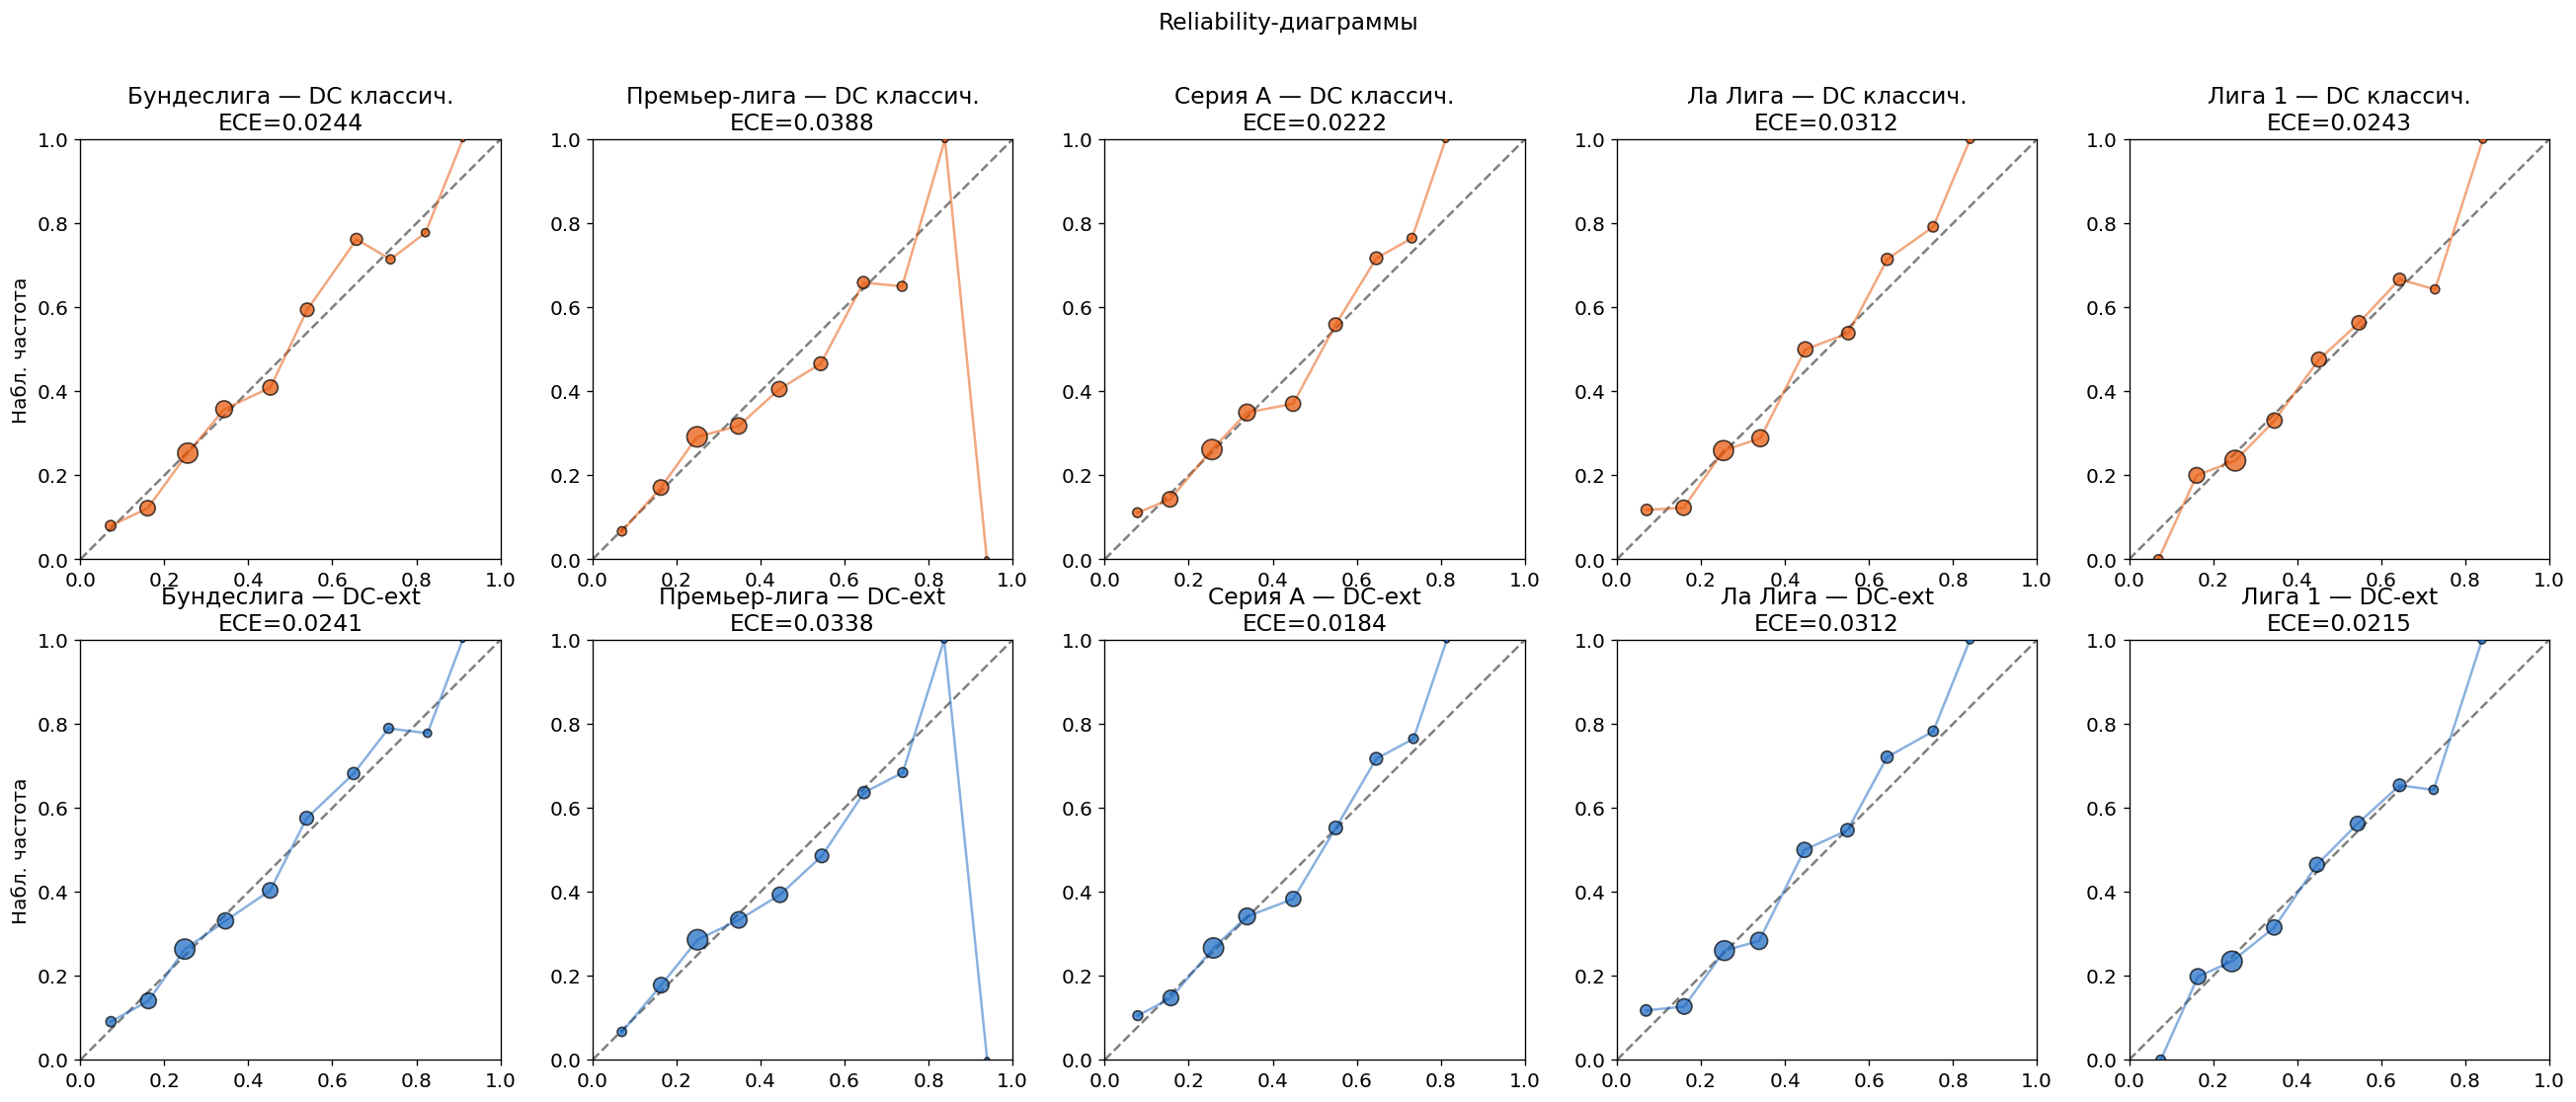

In [8]:
def calibration_analysis(preds_df, n_bins=10):
    ap, ao = [], []
    for _, row in preds_df.iterrows():
        for prob, lbl in [(row['p_home'],'H'),(row['p_draw'],'D'),(row['p_away'],'A')]:
            ap.append(prob); ao.append(1 if row['actual']==lbl else 0)
    ap, ao = np.array(ap), np.array(ao)
    edges = np.linspace(0,1,n_bins+1)
    ct, fr, cn_ = [], [], []
    for i in range(n_bins):
        m = (ap>=edges[i])&(ap<edges[i+1]) if i<n_bins-1 else (ap>=edges[i])&(ap<=edges[i+1])
        if m.sum()>0: ct.append(ap[m].mean()); fr.append(ao[m].mean()); cn_.append(m.sum())
        else: ct.append((edges[i]+edges[i+1])/2); fr.append(np.nan); cn_.append(0)
    tot = sum(cn_)
    ece = sum((c/tot)*abs(f-p) for p,f,c in zip(ct,fr,cn_) if c>0 and not np.isnan(f))
    return np.array(ct), np.array(fr), np.array(cn_), ece

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
ece_dc, ece_ext = {}, {}

for idx, (cn, info) in enumerate(LEAGUES.items()):
    for row_idx, (preds, label, color, ece_dict) in enumerate([
        (predictions_dc[cn], 'DC классич.', '#E65100', ece_dc),
        (predictions_dc_ext[cn], 'DC-ext', '#1565C0', ece_ext)
    ]):
        ax = axes[row_idx, idx]
        ct, fr, counts, ece = calibration_analysis(preds)
        ece_dict[cn] = ece
        v = ~np.isnan(fr)
        ax.plot([0,1],[0,1],'k--',alpha=0.5)
        ax.scatter(ct[v], fr[v], s=np.sqrt(counts[v])*8, c=color, alpha=0.7, edgecolors='black', zorder=5)
        ax.plot(ct[v], fr[v], '-', color=color, alpha=0.5)
        ax.set_title(f"{info['name']} — {label}\nECE={ece:.4f}")
        if idx==0: ax.set_ylabel('Набл. частота')
        ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')

plt.suptitle('Reliability-диаграммы', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('calibration_dc_both.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Сравнение с букмекером


In [ ]:
def bk_compare(preds_df):
    if 'B365H' not in preds_df.columns: return None
    df = preds_df.dropna(subset=['B365H','B365D','B365A']).copy()
    if len(df)==0: return None
    ti = 1/df['B365H']+1/df['B365D']+1/df['B365A']
    df['fh']=1/df['B365H']/ti; df['fd']=1/df['B365D']/ti; df['fa']=1/df['B365A']/ti
    n=len(df)
    a=np.zeros((n,3))
    for i,o in enumerate(df['actual']):
        if o=='H': a[i,0]=1
        elif o=='D': a[i,1]=1
        else: a[i,2]=1
    mp=np.clip(df[['p_home','p_draw','p_away']].values,1e-10,1)
    bp=np.clip(df[['fh','fd','fa']].values,1e-10,1)
    mll=-np.mean(np.sum(a*np.log(mp),1)); bll=-np.mean(np.sum(a*np.log(bp),1))
    return {'N':n, 'Модель LL':round(mll,4), 'Букм. LL':round(bll,4), 'Δ LL':round(mll-bll,4)}

print("Сравнение с букмекером:\n")
bk_rows = []
for cn, info in LEAGUES.items():
    for preds, label in [(predictions_dc[cn],'DC'), (predictions_dc_ext[cn],'DC-ext')]:
        r = bk_compare(preds)
        if r: r['Лига']=info['name']; r['Модель']=label; bk_rows.append(r)
if bk_rows:
    display(pd.DataFrame(bk_rows)[['Лига','Модель','N','Модель LL','Букм. LL','diff LL']])


Сравнение с букмекером:



,Лига,Модель,N,Модель LL,Букм. LL,diff LL
0,Бундеслига,DC,298,1.0190,0.9547,0.0643
1,Бундеслига,DC-ext,298,1.0221,0.9547,0.0674
2,Премьер-лига,DC,299,1.0666,1.0211,0.0455
3,Премьер-лига,DC-ext,299,1.0788,1.0211,0.0577
4,Серия А,DC,299,0.9912,0.9747,0.0166
5,Серия А,DC-ext,299,0.9915,0.9747,0.0168
6,Ла Лига,DC,299,0.9969,0.9492,0.0477
7,Ла Лига,DC-ext,299,1.0024,0.9492,0.0532
8,Лига 1,DC,298,0.9854,0.9626,0.0228
9,Лига 1,DC-ext,298,0.9824,0.9626,0.0198


## 7. Сравнение трёх моделей: Пуассон vs DC vs DC-ext


In [ ]:
poisson_ll = {}
for cn in LEAGUES:
    try:
        df = pd.read_csv(f'predictions_poisson_rolling_{cn}.csv')
        m = compute_metrics(df)
        poisson_ll[cn] = m
    except:
        pass

comp_rows = []
for cn, info in LEAGUES.items():
    mc = compute_metrics(predictions_dc[cn])
    me = compute_metrics(predictions_dc_ext[cn])
    pl = poisson_ll.get(cn, {})
    pll = pl.get('Log-Loss', np.nan)
    
    comp_rows.append({
        'Лига': info['name'],
        'Poisson LL': pll,
        'DC LL': mc['Log-Loss'],
        'DC-ext LL': me['Log-Loss'],
        'Δ (DC-P)': round(mc['Log-Loss'] - pll, 4) if not np.isnan(pll) else None,
        'Δ (ext-P)': round(me['Log-Loss'] - pll, 4) if not np.isnan(pll) else None,
        'Лучшая': 'DC-ext' if me['Log-Loss'] < mc['Log-Loss'] and me['Log-Loss'] < pll 
                  else ('DC' if mc['Log-Loss'] < pll else 'Poisson'),
    })

print("="*80)
print("Сравнение 3х моделей")
print("diff < 0 = модель лучше Пуассона")
print("="*80)
pd.DataFrame(comp_rows)


Сравнение 3х моделей
diff < 0 = модель лучше Пуассона


,Лига,Poisson LL,DC LL,DC-ext LL,diff (DC-P),diff (ext-P),Лучшая
0,Бундеслига,1.0510,1.0190,1.0221,-0.0320,-0.0289,DC
1,Премьер-лига,1.1068,1.0666,1.0788,-0.0402,-0.0280,DC
2,Серия А,0.9913,0.9912,0.9915,-0.0001,0.0002,DC
3,Ла Лига,1.0285,0.9969,1.0024,-0.0316,-0.0261,DC
4,Лига 1,0.9825,0.9854,0.9824,0.0029,-0.0001,DC-ext


In [ ]:
for cn in LEAGUES:
    predictions_dc[cn].to_csv(f'predictions_dc_rolling_{cn}.csv', index=False)
    predictions_dc_ext[cn].to_csv(f'predictions_dc_ext_rolling_{cn}.csv', index=False)